#**The frequency of Earthquakes**
CMSC320 Summer 2026 Data Science Project

Collaborators:

*   Anuja Annavarapu (A,C,D,E,F,G) (Add summary of contributions)

*   Natalie Figueira (A,B,C,D,E,G) (Add summary of contributions)

*   Ana Lungu (A,C,D,E,F,G) Helped with data exploration and ML Algorithm.

#**Introduction**

For this project we wanted to look at earthquakesOvertime earthquakes have been getting more frequent, and the magnitude has also been increasing.
We wanted to understand how earthquake's frequency and other characteristics like magnitude and depth differ throughout the northern hemisphere over time.

In this project we look at different Machine Learning Models to find out if certain features like location, and depth can

In [1]:
#imports
import pandas as pd
import string
import math
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.model_selection import train_test_split


## **PART 1 - DATA PROCESSING**


We are using Earthquake data from the USGS earthquake data website  [USGS Earthquake Database](https://earthquake.usgs.gov/earthquakes/search/).  

We downloaded a .CSV file that contains data is from June 1st, 2005 to September 27th, 2012. It includes earthquake data  has been reviewd in the context of Earthquakes.

Dataset citation:
USGS. (2019). Search Earthquake Catalog. Usgs.Gov. https://earthquake.usgs.gov/earthquakes/search/

In [2]:
earthquakes_df = pd.read_csv("Earthquakes.csv")
earthquakes_df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2005-06-01T12:24:21.490Z,18.4620,-68.7530,148.1,4.2,mb,47.0,47.7,NaN,NaN,...,2014-11-07T01:26:03.100Z,"9 km WNW of San Rafael del Yuma, Dominican Rep...",earthquake,NaN,NaN,NaN,11.0,reviewed,rspr,us
1,2005-06-01T21:55:04.580Z,17.0910,-46.4740,10.0,5.0,mwc,241.0,44.7,NaN,0.72,...,2025-12-19T23:08:34.930Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
2,2005-06-01T21:58:40.450Z,17.0670,-46.4480,10.0,4.8,mb,81.0,46.4,NaN,0.69,...,2014-11-07T01:26:04.203Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,30.0,reviewed,us,us
3,2005-06-02T04:50:07.800Z,19.4800,-103.5720,7.0,4.1,md,6.0,104.8,NaN,NaN,...,2014-11-07T01:26:04.430Z,"5 km NNW of Cofradía, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,unm,unm
4,2005-06-02T09:29:38.580Z,26.4510,-44.7070,10.0,4.7,mb,21.0,128.4,NaN,1.16,...,2014-11-07T01:26:04.558Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,12.0,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,2012-09-26T11:37:27.550Z,10.2180,-85.1100,57.1,4.2,mb,31.0,196.4,NaN,0.86,...,2014-11-07T01:48:55.204Z,"17 km WSW of Juntas, Costa Rica",earthquake,NaN,5.3,NaN,13.0,reviewed,us,us
15996,2012-09-26T18:15:22.200Z,14.8520,-61.2440,169.6,4.3,md,32.0,136.9,NaN,NaN,...,2014-11-07T01:48:55.280Z,"13 km W of Basse-Pointe, Martinique",earthquake,NaN,NaN,NaN,NaN,reviewed,trn,trn
15997,2012-09-26T22:23:23.940Z,26.8630,-44.2400,10.0,4.4,mb,40.0,88.6,NaN,1.04,...,2014-11-07T01:48:55.300Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,10.0,reviewed,us,us
15998,2012-09-27T03:03:41.090Z,9.8210,-85.5690,36.7,4.4,mb,60.0,139.7,NaN,1.36,...,2014-11-07T01:48:55.505Z,"8 km SW of Sámara, Costa Rica",earthquake,NaN,9.5,NaN,32.0,reviewed,us,us


Information about the dataset before any modifications take place

In [3]:
print(f"df.shape: {earthquakes_df.shape}")
earthquakes_df.shape
print("df.describe(): ")
display(earthquakes_df.describe())
print("df.info(): ")
earthquakes_df.info()



df.shape: (16000, 22)
df.describe(): 


,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,16000.000000,16000.000000,16000.000000,16000.00000,14720.000000,14717.000000,1490.000000,7664.000000,1513.000000,4770.000000,1176.000000,6173.000000
mean,27.611573,-104.703152,38.187911,4.10787,47.583628,168.173160,0.278961,0.850562,1.483323,14.140468,0.191622,51.673092
std,16.763399,31.873068,43.143381,0.49540,77.578092,79.883874,0.357982,0.889954,5.029209,155.091728,0.157575,84.415456
min,7.959000,-171.562000,-2.285000,3.50000,0.000000,11.900000,0.001802,0.009800,0.080000,0.000000,0.000000,0.000000
25%,15.886000,-120.798542,10.000000,3.70000,8.000000,107.000000,0.054320,0.570000,0.300000,0.500000,0.134000,5.000000
50%,18.629000,-98.362000,19.000000,4.00000,18.000000,170.200000,0.166600,0.920000,0.580000,4.025000,0.163000,15.000000
75%,40.308958,-87.848000,51.700000,4.40000,49.000000,219.800000,0.392775,1.150000,1.630000,12.000000,0.200000,50.000000
max,72.852000,-36.609000,294.900000,7.60000,857.000000,358.300000,5.654000,69.320000,99.000000,9117.600000,1.680000,438.000000


df.info(): 
<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             16000 non-null  str    
 1   latitude         16000 non-null  float64
 2   longitude        16000 non-null  float64
 3   depth            16000 non-null  float64
 4   mag              16000 non-null  float64
 5   magType          16000 non-null  str    
 6   nst              14720 non-null  float64
 7   gap              14717 non-null  float64
 8   dmin             1490 non-null   float64
 9   rms              7664 non-null   float64
 10  net              16000 non-null  str    
 11  id               16000 non-null  str    
 12  updated          16000 non-null  str    
 13  place            16000 non-null  str    
 14  type             16000 non-null  str    
 15  horizontalError  1513 non-null   float64
 16  depthError       4770 non-null   float64
 17  magError   

Parse data: Sort by magnitude

In [4]:
#sort by mag highest to smallest
earthquakes_df = earthquakes_df.sort_values(by=['mag'], ascending=False).reset_index(drop='True')

#this line below is to check if there was mag error, there is, maybe we could use it
#earthquakes_df = earthquakes_df.dropna(subset=['magError', "depthError", "horizontalError"])
earthquakes_df = earthquakes_df.dropna(subset=['gap'])
#date only column, in datetime (remove .dt.date to get full date and time in datetime format)
date = pd.to_datetime(earthquakes_df['time']).dt.date
earthquakes_df.insert(0, 'date', date)
display(earthquakes_df)

,date,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2012-09-05,2012-09-05T14:42:07.800Z,10.085,-85.315,35.0,7.6,mww,703.0,34.3,NaN,...,2025-01-03T07:43:01.170Z,"11 km ENE of Hojancha, Costa Rica",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
1,2012-03-20,2012-03-20T18:02:47.440Z,16.493,-98.231,20.0,7.4,mww,672.0,37.9,NaN,...,2022-05-03T15:34:09.063Z,"6 km E of Santiago Llano Grande, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
2,2007-11-29,2007-11-29T19:00:20.420Z,14.944,-61.274,156.0,7.4,mwb,663.0,13.4,NaN,...,2022-07-13T02:37:48.411Z,"18 km WNW of Basse-Pointe, Martinique",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
3,2009-05-28,2009-05-28T08:24:46.560Z,16.731,-86.217,19.0,7.3,mwc,464.0,27.2,NaN,...,2025-07-03T19:11:11.454Z,"46 km NW of Guanaja, Honduras",earthquake,NaN,NaN,NaN,NaN,reviewed,us,gcmt
4,2012-08-27,2012-08-27T04:37:19.430Z,12.139,-88.590,28.0,7.3,mww,417.0,37.0,NaN,...,2022-05-03T15:48:15.643Z,"126 km S of Puerto El Triunfo, El Salvador",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15993,2008-06-19,2008-06-19T16:40:55.560Z,54.490,-161.588,14.5,3.5,ml,15.0,111.7,NaN,...,2019-02-28T20:01:36.803Z,"79 km SE of King Cove, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,aeic,aeic
15994,2008-06-19,2008-06-19T23:03:53.740Z,54.475,-161.561,13.9,3.5,ml,6.0,216.6,NaN,...,2019-02-13T09:22:05.981Z,"81 km SE of King Cove, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,aeic,aeic
15995,2005-06-07,2005-06-07T15:48:56.030Z,18.540,-66.082,106.6,3.5,md,14.0,193.8,NaN,...,2014-11-07T01:26:09.142Z,"8 km NNE of San Juan, Puerto Rico",earthquake,NaN,NaN,NaN,NaN,reviewed,rspr,rspr
15996,2006-05-10,2006-05-10T02:49:16.060Z,52.539,-169.198,25.3,3.5,ml,5.0,215.0,NaN,...,2019-02-13T04:32:18.731Z,"49 km SSW of Nikolski, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,aeic,aeic


##**Exploratory Data Analysis**

(SOME EXPLAINATION HERE)


### Method 1: Frequency of Earthquakes Based on Geographical Region using Chi Square Test


We will first examine the frequency of earthquakes based off of geographical region. To better visualize the correlation between how often the earthquakes happen and which locations get the most number of earthquakes, we will use a bar chart and a pie chart. First, we want to see how frequent are the earthquakes in the locations in our database. We notice that most of the locations have only 1 earthquake, with the graph being extremely right skewed that is almost imposible to be seen on the graph. From this first graph we understand that most of the locations in our data base have less than 10 earthquakes.

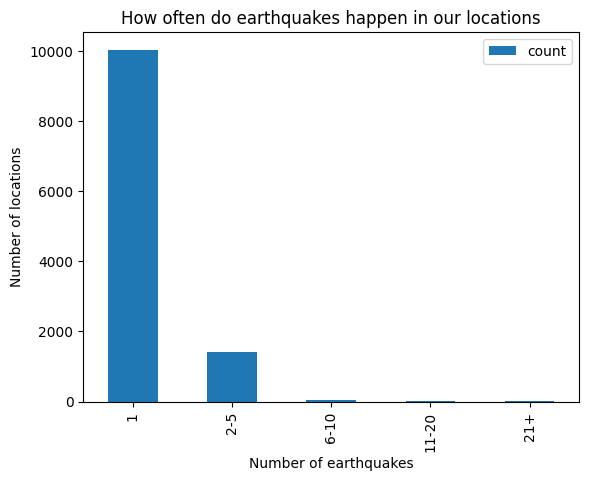

In [5]:
place_types = earthquakes_df['place'].value_counts()
#print(place_types.count())

bins = [0,1, 5, 10, 20, float('inf')]
labels = ['1','2-5','6-10', '11-20', '21+']

binned = pd.cut(place_types, bins = bins, labels=labels)
binned_occurences = binned.value_counts().sort_index()

binned_occurences.plot(kind='bar')
plt.title('How often do earthquakes happen in our locations')
plt.xlabel('Number of earthquakes')
plt.ylabel('Number of locations')
plt.legend()

plt.show()

There is a lot of locations that only experience one earthquake. We wanted to see exactly which locations are prone to having more earthquakes and their exact number of earthquakes. More specifically, we wanted to take a closer look at the locations that have more than 10 earthquakes.

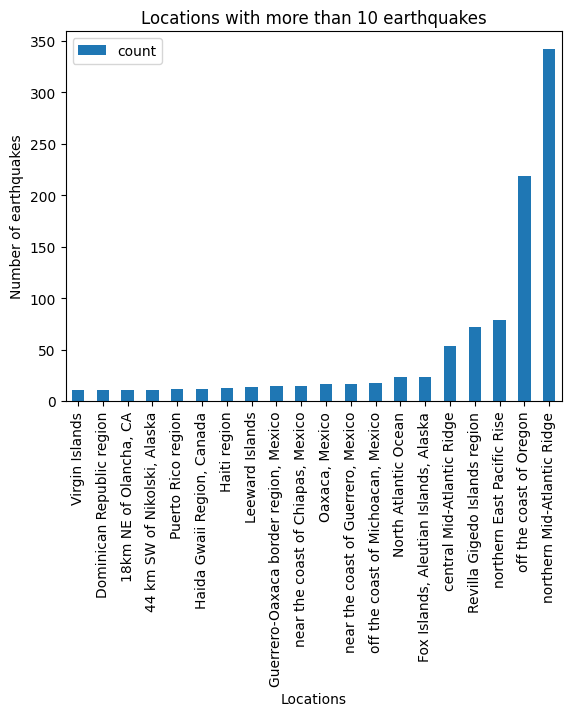

In [6]:
place_types_more_than_10_occurences = place_types[place_types > 10]

place_types_more_than_10_occurences.sort_values().plot(kind='bar')

plt.title("Locations with more than 10 earthquakes")
plt.ylabel('Number of earthquakes')
plt.xlabel('Locations')
plt.legend()
plt.show()

Notice that there are 2 locations with an astonishing amount of earthquakes, more than 100. These 2 locations are the outliers that are skewing the graph. This made us wonder what is the distribution of the frequency of earthquakes.

---
---
---

Among our dataset, we wondered what is the percentage of locations that suffered 1 earthquake, between 2 and 10, and finally, more than 11. For this question we used the pie chart which perfectly shows that almost 88% of the locations have suffered only 1 earthquake, while 0.174% have suffered more than 11 earthquakes.

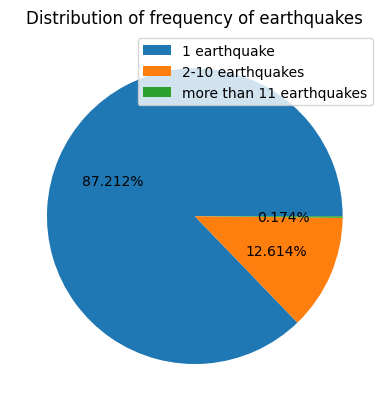

In [7]:
bins = [0,1, 10, float('inf')]
labels = ['1','2-10', '11+']

binned = pd.cut(place_types, bins = bins, labels=labels)
binned_occurences = binned.value_counts().sort_index()


legend=['1 earthquake', '2-10 earthquakes', 'more than 11 earthquakes']
myexplode=[0, 0, 0.7]
binned_occurences.plot(kind='pie', labels=None, autopct='%1.3f%%')
plt.title('Distribution of frequency of earthquakes')
plt.legend(legend)
plt.show()

This brought us to our next question, are certain areas more prone to earthquakes with higher or lower frequency? We want to see the relationship and the ratio between the frequency of the earthquakes and the areas where these earthquakes happened. We will be using the Chi-Square Test for Independence and our Null Hypothesis is that there is no relation.

In [8]:
#place_types = earthquakes_df['place'].value_counts()

my_places = place_types

my_places = my_places.reset_index()
my_places.columns = ['place', 'count']

#calculate the average latitude for each place
latitude_table = earthquakes_df.groupby('place', as_index=False)['latitude'].mean()

earthquake_dataframe = pd.merge(
    my_places,
    latitude_table,
    on='place',
    how='inner'
)

#this is variable 1
bins = [0, 1, 10, float('inf')]
labels = ['1 earthquake', '2 to 10 earthquakes', 'more than 10 earthquakes']
earthquake_dataframe['count category'] = pd.cut(earthquake_dataframe['count'], bins = bins, labels=labels)

#this is variable 2
bins = [0, 30, 60, 90]
labels = ['Low Latitude', 'Mid Latitude', 'High Latitude']
earthquake_dataframe['region category'] = pd.cut(earthquake_dataframe['latitude'], bins = bins, labels=labels)


#i need contingency table
contingency_table = pd.crosstab(earthquake_dataframe['count category'], earthquake_dataframe['region category'])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(contingency_table)

print("\np-value:", p_value)

if p_value <= 0.05:
    print('\nDependent (reject H0)')
else:
    print('\nIndependent (H0 holds true)')

region category           Low Latitude  Mid Latitude  High Latitude
count category                                                     
1 earthquake                      7725          2182            132
2 to 10 earthquakes                849           596              7
more than 10 earthquakes            15             5              0

p-value: 2.439665075327352e-55

Dependent (reject H0)


The Chi-square test shows that there is a relation between the lower, middle, higher part of the locations in our dataframe, and the earthquake frequency. From the table we can see that locations with only one earthquake are predominantly in the lower region, and the earthquakes are not evenly distributed across lower, middle and higher regions.

### Method 2: Comparison of Earthquake Characteristics Across Latitude Regions using ANOVA testing

We have three divides of the regions: Low Latitude, Mid Latitude, and High Latitude

Having examined how earthquake frequency varies across latitude regions, we now investigate whether the characteristics of the earthquake events themselves (depth and magnitude) also differ across those regions. Earlier we observed that the Low Latitude region contains the largest number of earthquake locations across all frequency categories, followed by the Mid Latitude region, while the High Latitude region has the fewest. Let's perform Anova to examine the average depths across the different regions:

In [9]:
#divide the dataframe into the regions
groups = earthquake_dataframe.groupby("region category",observed=False)

low = groups.get_group("Low Latitude")
mid = groups.get_group("Mid Latitude")
high = groups.get_group("High Latitude")

#grab the places within each region from the original dataframe
low_places = low["place"]
low_earthquakes = earthquakes_df[earthquakes_df["place"].isin(low_places)]

mid_places = mid["place"]
mid_earthquakes = earthquakes_df[earthquakes_df["place"].isin(mid_places)]

high_places = high["place"]
high_earthquakes = earthquakes_df[earthquakes_df["place"].isin(high_places)]

#print the avg depths
print("Mean depth of lower lat regions:",low_earthquakes['depth'].mean())
print("Mean depth of middle lat regions:", mid_earthquakes['depth'].mean())
print("Mean depth of higher lat regions:", high_earthquakes['depth'].mean())

#perform the ANOVA test
f_stat, p_value = stats.f_oneway(low_earthquakes["depth"].dropna(), mid_earthquakes["depth"].dropna(), high_earthquakes["depth"].dropna())
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value <= 0.05:
    print("Reject H0: at least one region has a significantly different mean depth.")
else:
    print("Fail to reject H0: no significant difference in mean depth across regions.")

Mean depth of lower lat regions: 45.999140084146106
Mean depth of middle lat regions: 16.52678526110298
Mean depth of higher lat regions: 10.621739130434783
F-statistic: 804.6526650655514
p-value: 0.0
Reject H0: at least one region has a significantly different mean depth.


We see that between the three regions, there is at least one region with a significantly different mean depth. Let's dig down further and see exactly which region is significantly different using Tukey's HSD test:

In [10]:
#because depth and region category are from two different dataframes, we merge them by stacking each column
tukey_df = pd.DataFrame({
    "depth": pd.concat([low_earthquakes["depth"],mid_earthquakes["depth"],high_earthquakes["depth"]], ignore_index=True),
    "region category": (["Low Latitude"] * len(low_earthquakes) + ["Mid Latitude"] * len(mid_earthquakes) + ["High Latitude"] * len(high_earthquakes))
})

tukey = pairwise_tukeyhsd(endog=tukey_df["depth"], groups=tukey_df["region category"], alpha=0.05)

print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1       group2    meandiff p-adj   lower    upper   reject
-------------------------------------------------------------------
High Latitude Low Latitude  35.3774    0.0  27.7893  42.9655   True
High Latitude Mid Latitude    5.905 0.1686  -1.7718  13.5819  False
 Low Latitude Mid Latitude -29.4724    0.0 -31.2333 -27.7114   True
-------------------------------------------------------------------


Here we can see that all three regions have significally different mean depths from the others. This suggests a strong relationship between latitude region and earthquake depth.

Let's plot the data to observe other statistical characteristics:

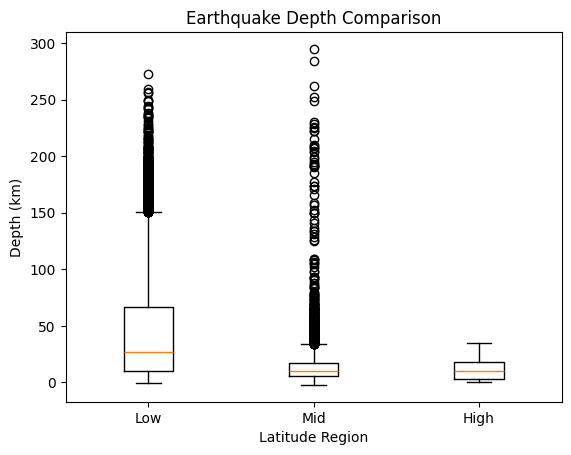

In [11]:
data = [
    low_earthquakes["depth"],
    mid_earthquakes["depth"],
    high_earthquakes["depth"]
]

plt.boxplot(data, tick_labels=["Low", "Mid", "High"])
plt.title("Earthquake Depth Comparison")
plt.xlabel("Latitude Region")
plt.ylabel("Depth (km)")
plt.show()

The box plot shows that the three latitude regions have different distributions of earthquake depths. The Low Latitude region has the highest median depth, the Mid Latitude region has the lowest median depth, and the High Latitude region is in between those two. These visual differences are consistent with our ANOVA and Tukey HSD results. One thing to note is that there are so many outliers for the earthquake depth.

Now let's do the same analysis for magnitude:

In [12]:
#print the avg mags
print("Mean magnitude of lower lat regions:",low_earthquakes['mag'].mean())
print("Mean magnitude of middle lat regions:", mid_earthquakes['mag'].mean())
print("Mean magnitude of higher lat regions:", high_earthquakes['mag'].mean())

#perform the ANOVA test
f_stat, p_value = stats.f_oneway(low_earthquakes["mag"].dropna(), mid_earthquakes["mag"].dropna(), high_earthquakes["mag"].dropna())
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value <= 0.05:
    print("Reject H0: at least one region has a significantly different mean magnitude.")
else:
    print("Fail to reject H0: no significant difference in mean magnitude across regions.")

Mean magnitude of lower lat regions: 4.15396921017403
Mean magnitude of middle lat regions: 4.032335285505125
Mean magnitude of higher lat regions: 4.104347826086957
F-statistic: 89.69772208110496
p-value: 1.9069341671253627e-39
Reject H0: at least one region has a significantly different mean magnitude.


Here we see that at least one region has a significantly different mean magnitude. Let's dig down even further and perform Tukey's HSD test for this result as well:

In [13]:
#because mag and region category are from two different dataframes, we merge our two necessary columns by stacking each column
tukey_df = pd.DataFrame({
    "mag": pd.concat([low_earthquakes["mag"],mid_earthquakes["mag"],high_earthquakes["mag"]], ignore_index=True),
    "region category": (["Low Latitude"] * len(low_earthquakes) + ["Mid Latitude"] * len(mid_earthquakes) + ["High Latitude"] * len(high_earthquakes))
})

tukey = pairwise_tukeyhsd(endog=tukey_df["mag"], groups=tukey_df["region category"], alpha=0.05)

print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1       group2    meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------
High Latitude Low Latitude   0.0496 0.4137 -0.0421  0.1414  False
High Latitude Mid Latitude   -0.072 0.1636 -0.1649  0.0208  False
 Low Latitude Mid Latitude  -0.1216    0.0 -0.1429 -0.1003   True
-----------------------------------------------------------------


Here we can see that all three regions have significantly different mean magnitudes from one another. This indicates that earthquake magnitude varies significantly across latitude regions, which is the same conclusion we derived for the earthquake depth.

Let's plot for magnitude:

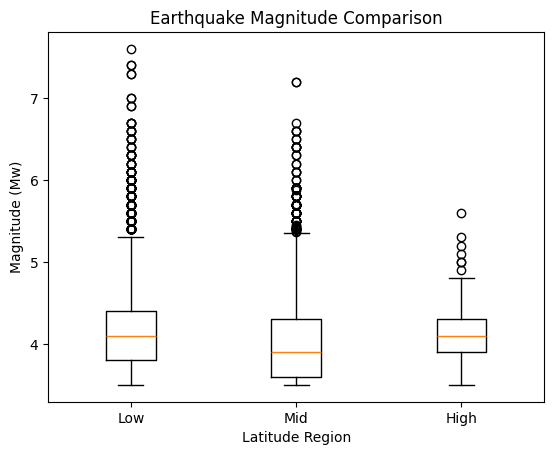

In [14]:
data = [
    low_earthquakes["mag"],
    mid_earthquakes["mag"],
    high_earthquakes["mag"]
]

plt.boxplot(data, tick_labels=["Low", "Mid", "High"])
plt.title("Earthquake Magnitude Comparison")
plt.xlabel("Latitude Region")
plt.ylabel("Magnitude (Mw)")
plt.show()

Here we see that the Low Latitude region has the highest median earthquake magnitude, while the Mid Latitude and High Latitude regions have slightly lower and more similar medians. This is still consistent with the Anova and Tukey HSD test results. Notice that there are fewer outliers in the magnitude data as well.

### Method 3: Magnitude vs Depth using Pearson Correlation

Earlier, we found that the Low Latitude region has the highest earthquake frequency, as well as the highest average magnitude and depth. We now focus on this region to investigate whether earthquake magnitude and depth are correlated.

Pearson correlation (Magnitude vs. Depth): -0.06725127908739693


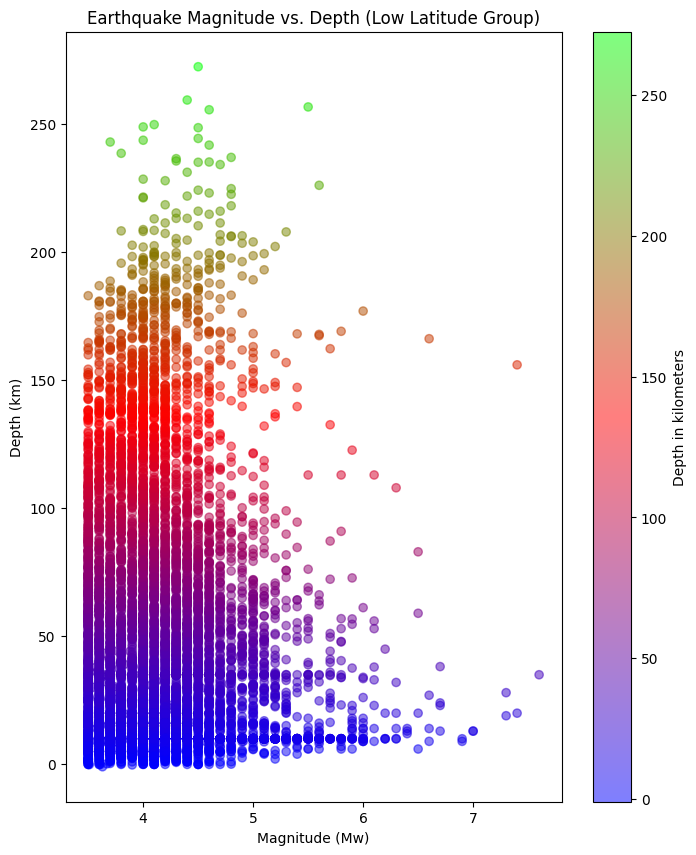

In [15]:
south_locations = earthquake_dataframe[earthquake_dataframe['region category'] == 'Low Latitude']['place']
region = earthquakes_df[earthquakes_df['place'].isin(south_locations)].copy()

rvalue = region['mag'].corr(region['depth'])
print(f"Pearson correlation (Magnitude vs. Depth): {rvalue}")
region['date'] = pd.to_datetime(region['date'])

plt.figure(figsize=(8, 10))
#use colors to help show the differences in depth used 0.5 alpha so the colors show better
plt.scatter(region['mag'], region['depth'], c=region['depth'], cmap='brg', alpha=0.5)
plt.colorbar(label="Depth in kilometers")

plt.title("Earthquake Magnitude vs. Depth (Low Latitude Group)")
plt.xlabel("Magnitude (Mw)")
plt.ylabel("Depth (km)")
plt.show()

Now looking at the data below looks superoverwhelming but thats because there is a lot of earthquakes that happened in a Low Latitude region as mentioned before. Looking at the graph it can be said that after a mag magnitude of 5.5 the depth of a earthquake is likely to be smaller than 175km.

There is a weak negative correlation but because there is so much data, we need to break some of this information down. We are going to still look at the south group. But we are going to visualize how many earthquakes there are by date.

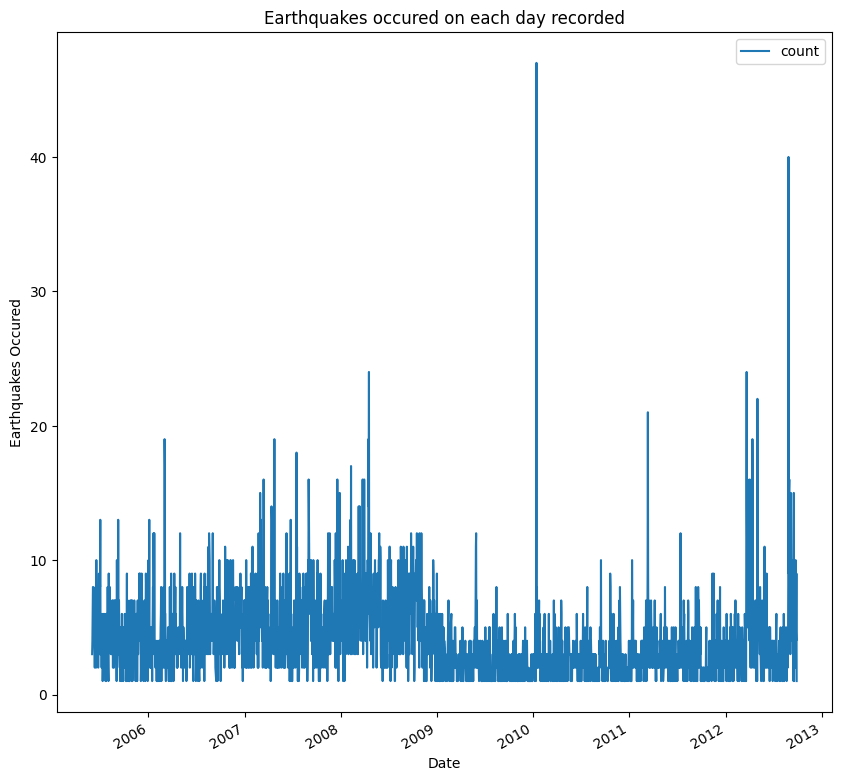

In [16]:
plt.figure(figsize=(10, 10))
region['date'].value_counts().sort_index().plot()
plt.xlabel("Date")
plt.ylabel("Earthquakes Occured")
plt.legend()
plt.title("Earthquakes occured on each day recorded")
plt.show()

We can see a huge spikes of earthquakes in around 2008, 2010, 2011, and 2012. But we are going to break this down a little further, and see the break down in just 2010 and see if there is more of a corrleation between Depth and magnitude since there will be less data points.

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2005 for depth and mag is: -0.011429004541155295


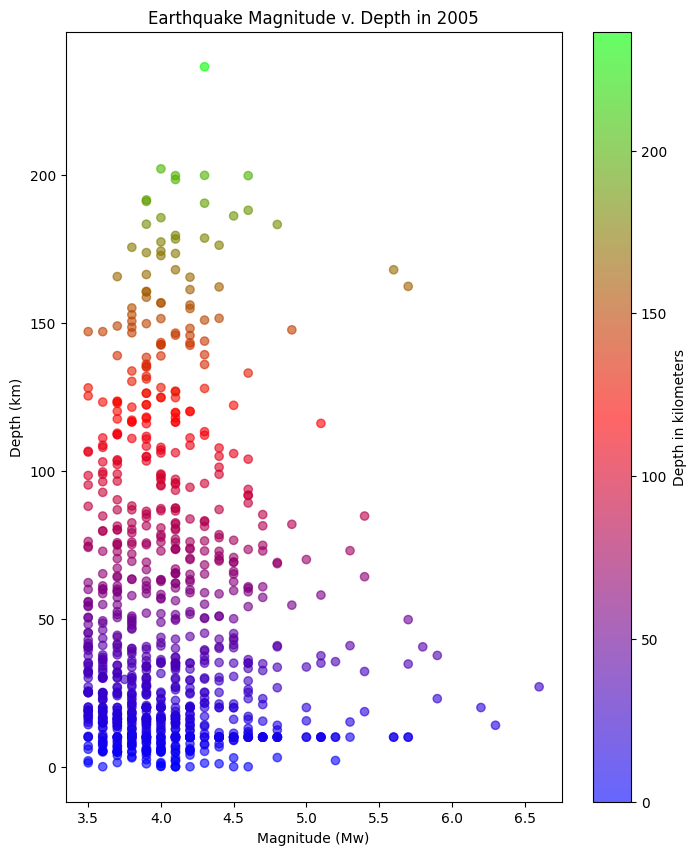

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2006 for depth and mag is: -0.0937610324061293


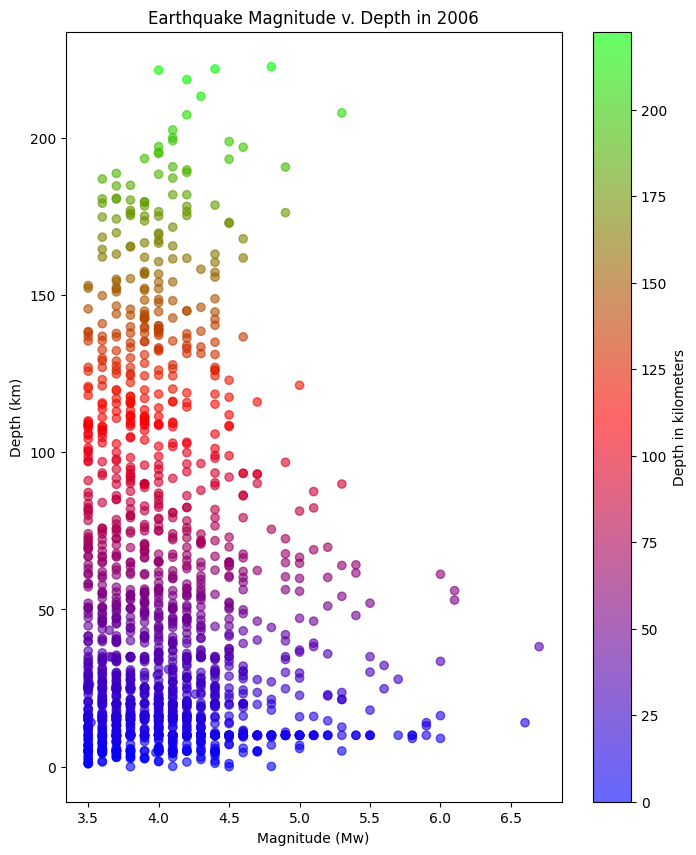

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2007 for depth and mag is: -0.01516564970735063


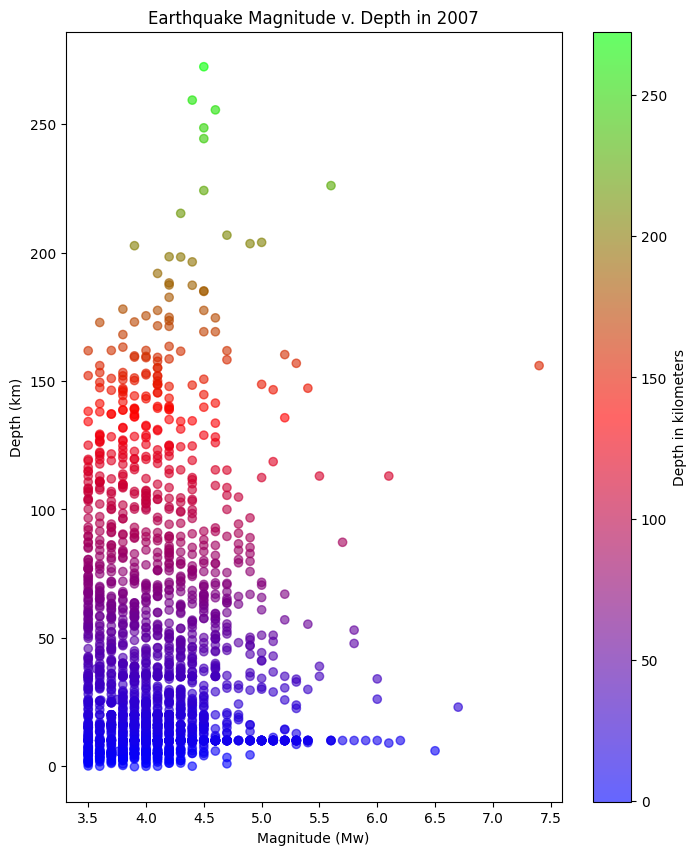

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2008 for depth and mag is: -0.023181015939224954


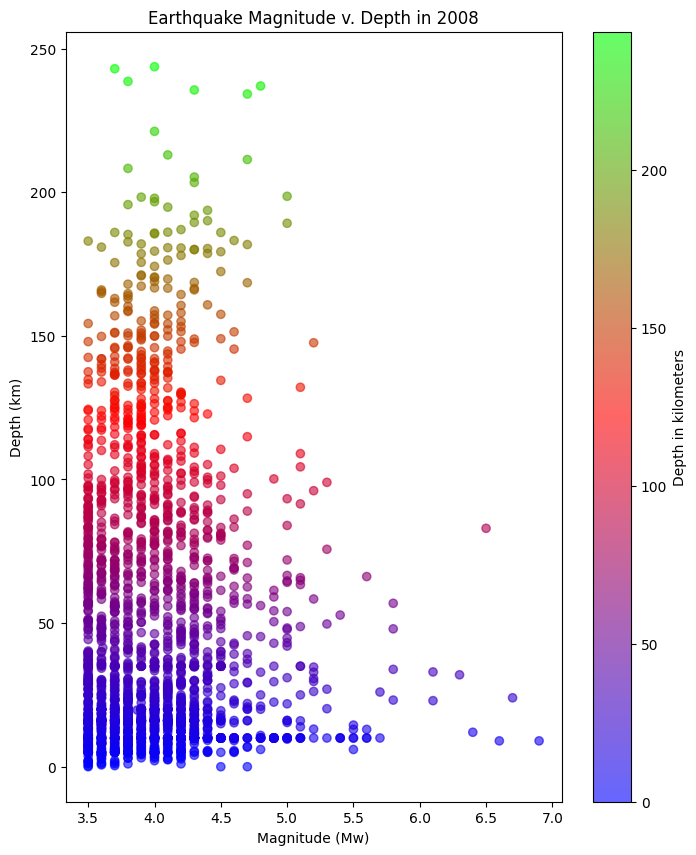

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2009 for depth and mag is: -0.14817625437687165


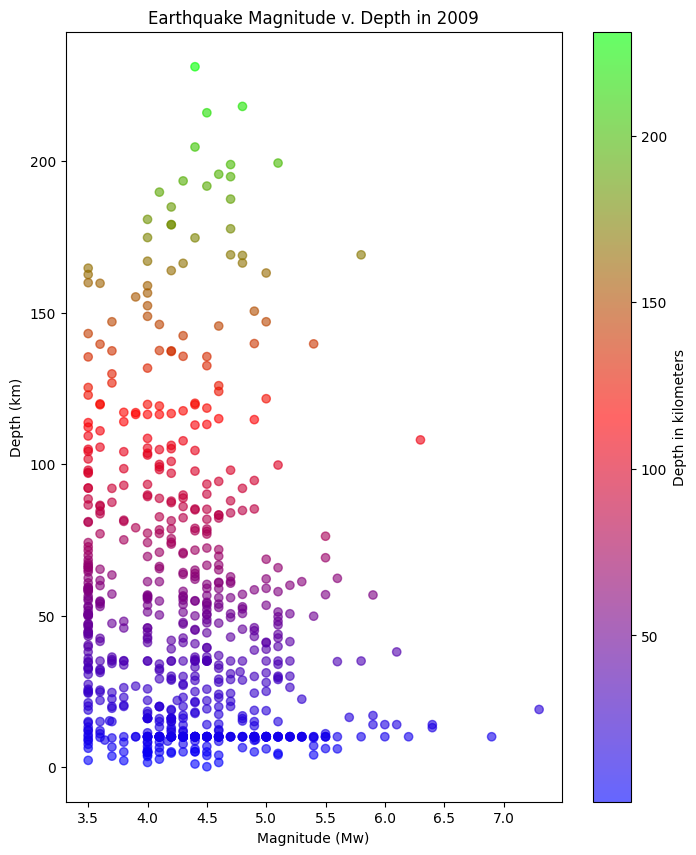

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2010 for depth and mag is: -0.024524940684534098


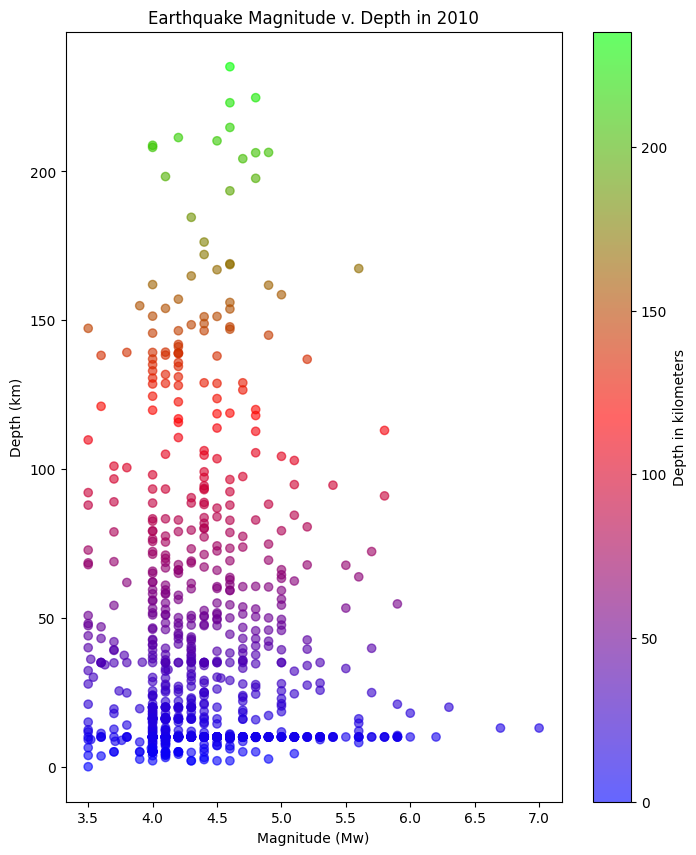

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2011 for depth and mag is: -0.06058938522492409


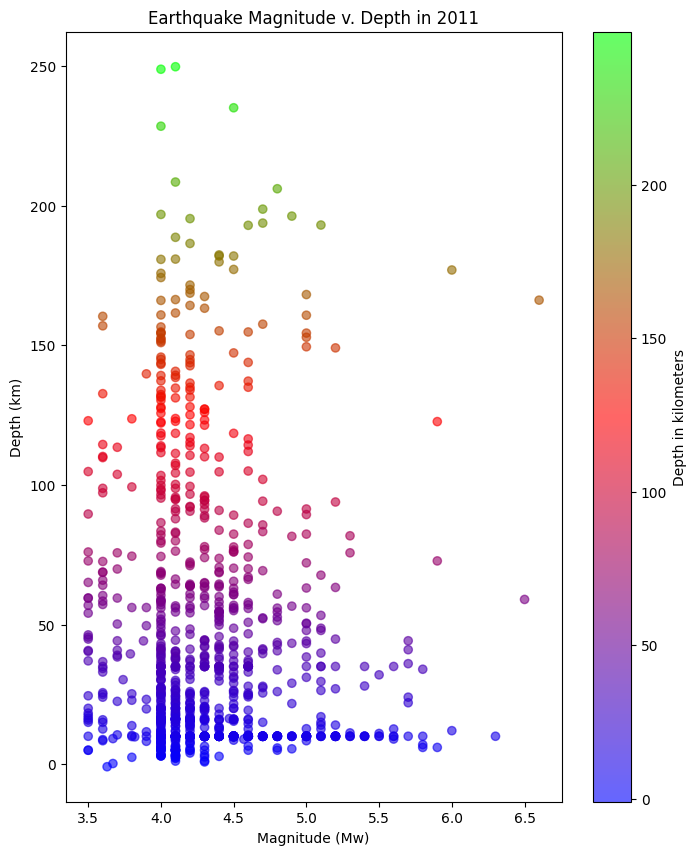

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2012 for depth and mag is: -0.09791611622036775


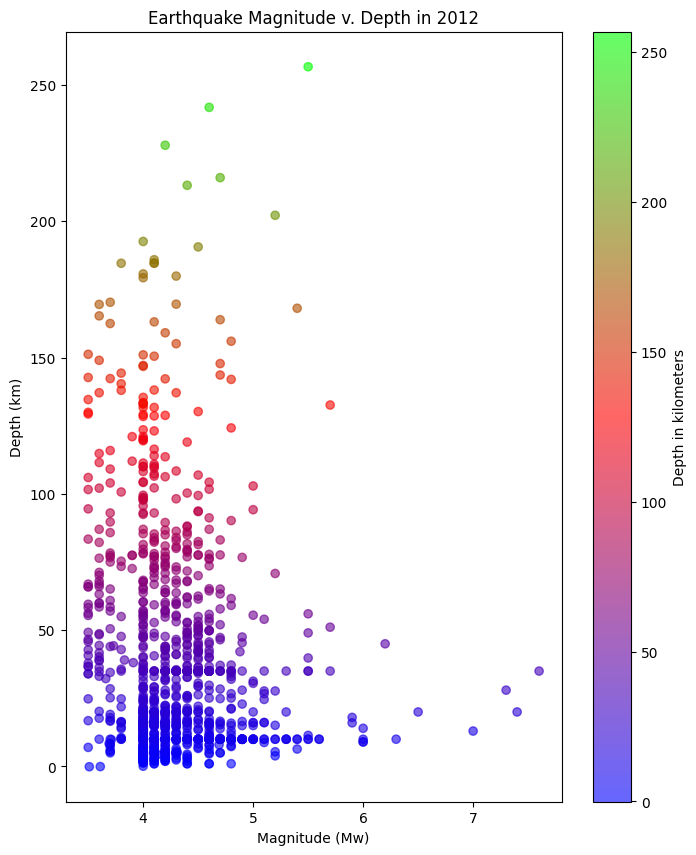

In [17]:
region['year'] = pd.to_datetime(region['date']).dt.year
south_earthquakes = region.groupby(region['year'])
#year = south_earthquakes.get_group(2010)
for x, groupTemp in south_earthquakes:
  year = groupTemp
  rvalue2010 = year['depth'].corr(year['mag'])
  print("-----------------------------------------------------------------------------------------------------------------------------------------------------------")
  print(f"Pearson r value for {x} for depth and mag is: {rvalue2010}")
  plt.figure(figsize=(8, 10))
  plt.scatter(year['mag'], year['depth'], c=year['depth'], cmap='brg', alpha=0.6)
  plt.colorbar(label="Depth in kilometers")
  plt.xlabel("Magnitude (Mw)")
  plt.ylabel("Depth (km)")
  plt.title(f"Earthquake Magnitude v. Depth in {x}")
  plt.show()
#then find magnitude v depth
#rvalue2010 = year['depth'].corr(year['mag'])
#print(f"Pearson r value for 2010 for depth and mag is: {rvalue2010}")
#plt.figure(figsize=(8, 10))
#plt.scatter(year['mag'], year['depth'], c=year['depth'], cmap='brg', alpha=0.6)
#plt.colorbar(label="Depth (km)")
#plt.xlabel("Magnitude")
#plt.ylabel("Depth (km)")
#plt.title("Earthquake Magnitude v. Depth in 2010")
#plt.show()

There is still a lot of data points and the R-value is still small but looking at the graphs is way more clear to see that around a magnitude of 5.5 or higher there is a negaitive correlation. The higher the magnitude leads to much smaller depth.

The graphs show more details than before.

1.   Looking over at the high concentrated years of 2008, 2010, 2011 and 2012 there was as 3 years (2008, 2011, and 2012) where depths reached 250km or more.

2.   Looking at all the years it is also seen that in 2010 was the start in seeing less earthquakes with a magnitude less than 4. There is much more data points starting with a magnitude of 4 which indicate that earthquakes have become a little more stronger starting in the 2010s.

3.   2012 has the high negative corrleation rate out of all the years with a -0.0979 percentage. While still weak, this allows us to see a much more clear correlation between the magnitude of an earthquake and the depth.




#**Model: Analysis, Hypothesis Testing, Machine Learning**


<font color="red">
**TRY CLUSTERING: checking if different regions have different behaviors when it comes to earthquakes**
</font>
<br>
<br>
<font color="blue">
**TRY: checking if region can help predict or explain the amount of magnitude and depth**

</font>


In this phase we perform many modeling techniques, in order to get predictive model of the earthquakes. (EXPLAIN THE MODELS WE USED)

Train on 2005-2010
Test on 2011-2012 (**50/50 on the idea because of the execution of it**)

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

train_set = region[region['year'] <= 2010]
#future
test_set = region[region['year'].isin([2011,2012])]

#basically test on 2005-2010 data and see if its can predict magnuitde or regions earthquakes will occur a
#nd test it with the 2011-2012 (50/50 on the idea because of the execution of it)


In [19]:
#K-cluster of the earthquakes (from region so they are all low lat)
locations_coordSort = region[["latitude", "longitude"]]

scaler = StandardScaler()
scaled = scaler.fit_transform(locations_coordSort)

k_mean = KMeans(n_clusters=5, random_state=42)
region["cluster"] = k_mean.fit_predict(scaled)
print(region["cluster"].value_counts())

cluster
0    5513
1    2420
2    1797
3     532
4     196
Name: count, dtype: int64


Linear Regression Model (**I Don't Know Maybe delete maybe keep**)

In [20]:
#work if location and/or depth has an impact on magnitude (maybe based on years)

X = region[["depth", "latitude", "longitude", "year"]]
Y = region["mag"]

X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

#Linear Regression
linear = LinearRegression()
linear.fit(X_train, y_train)
linear_pred = linear.predict(X_test)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)
linear_mae = mean_absolute_error(y_test, linear_pred)

print(f"MSE: {linear_mse}")
print(f"MAE: {linear_mae}")
print(f"R2 score: {linear_r2}")

MSE: 0.23426566190897122
MAE: 0.35899743641788995
R2 score: 0.050367804397259075


Random Forest model

Get the $R^2$ and MSE

In [21]:
#work if location and/or depth has an impact on magnitude (maybe based on years)
#Random Forest
randF_model = RandomForestRegressor(n_estimators=350, random_state=42)
randF_model.fit(X_train, y_train)
randF_predict = randF_model.predict(X_test)


mse = mean_squared_error(y_test, randF_predict)
r2 = r2_score(y_test, randF_predict)
mae = mean_absolute_error(y_test, randF_predict)
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 score: {r2}")

MSE: 0.16833089062746318
MAE: 0.28449531548757157
R2 score: 0.31764462639669033


In [22]:
from scipy.special import kn
#work if location and/or depth has an impact on magnitude (maybe based on years)
#KNN
kn_model = KNeighborsRegressor(n_neighbors=10)
kn_model.fit(X_train, y_train)
kn_predict = kn_model.predict(X_test)


kn_mse = mean_squared_error(y_test, kn_predict)
kn_r2 = r2_score(y_test, kn_predict)
kn_mae = mean_absolute_error(y_test, kn_predict)

print(f"MSE: {kn_mse}")
print(f"MAE: {kn_mae}")
print(f"R2 score: {kn_r2}")

MSE: 0.17457715344168262
MAE: 0.29198900573613773
R2 score: 0.2923244312718759


#**Visualization**



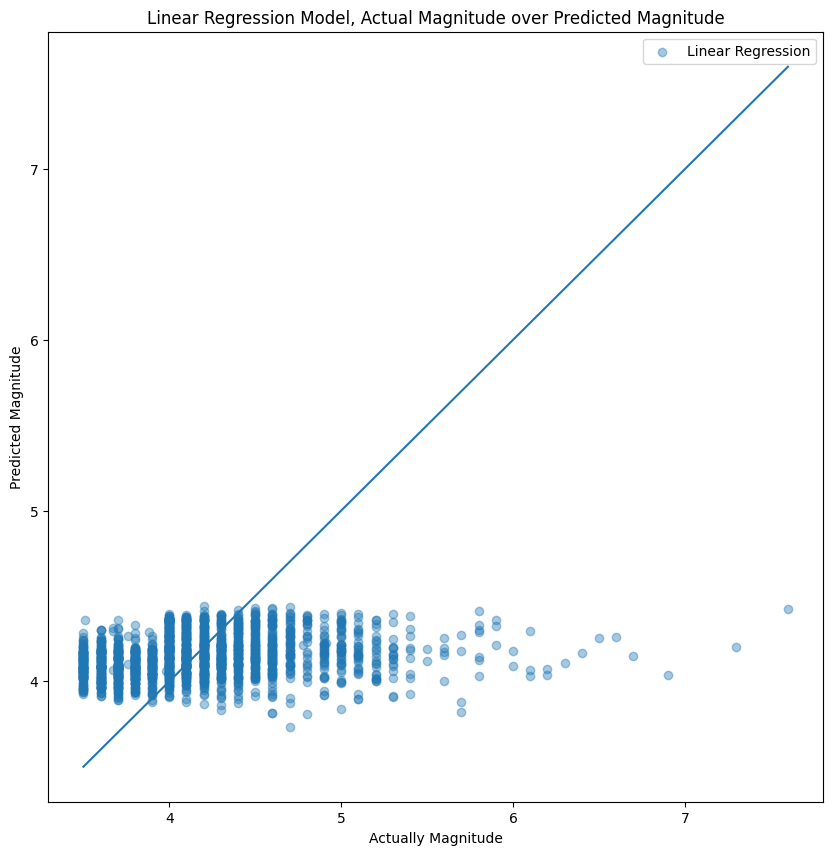

In [23]:
#plot for Linear regression
plt.figure(figsize=(10,10))
plt.scatter(y_test, linear_pred, label="Linear Regression", alpha=0.4)
#how to plot line regression using min max of y_test
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actually Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Linear Regression Model, Actual Magnitude over Predicted Magnitude")
plt.legend()
plt.show()

It looks like linear regression didn't work that well with the Earthquake data. It often predicted between 4 to 7 even when including year as a parameter.

That's why we also ran a Random Forest Regression model on the exact same way.
If it on the solid blue line it means the model predicted more accurately.

Lets see if it improves if we change to the Random Forest Model.

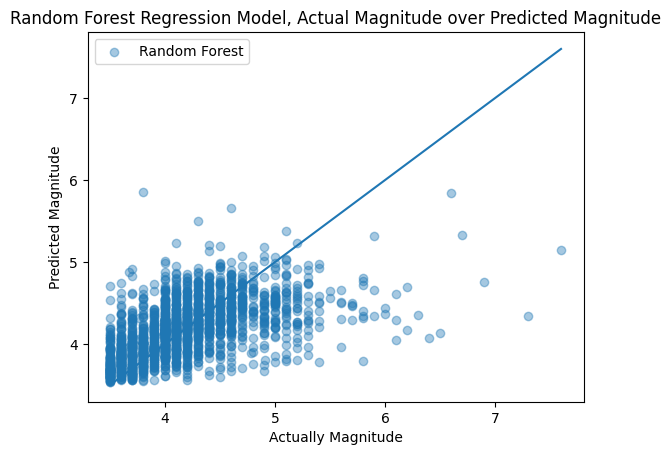

In [24]:
#random forest version
plt.scatter(y_test, randF_predict, alpha=0.4, label="Random Forest")
#how to plot line regression using min max of y_test
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actually Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Random Forest Regression Model, Actual Magnitude over Predicted Magnitude")
plt.legend()
plt.show()

It way more clear to see that using random forest did improve the predictive model. It is clear to see that there is an upward trend and more centerd around the 4-5 mag area.

Compared to the linear regression it did a lot better but its still isn't great for the low latitude region. In fact random forest regression has made the points predict a larger magnitude than expected.

Both models currently underpredict for large earthquakes magnitudes. Greater than or equal to 6

Trying

Year: 2005
MSE: 0.1315675059198535
R2 score: 0.14591627431273546


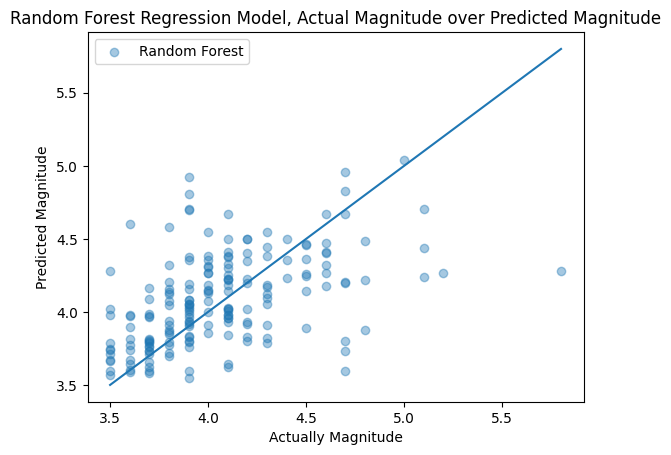

Year: 2006
MSE: 0.11602896814222356
R2 score: 0.3720133956143965


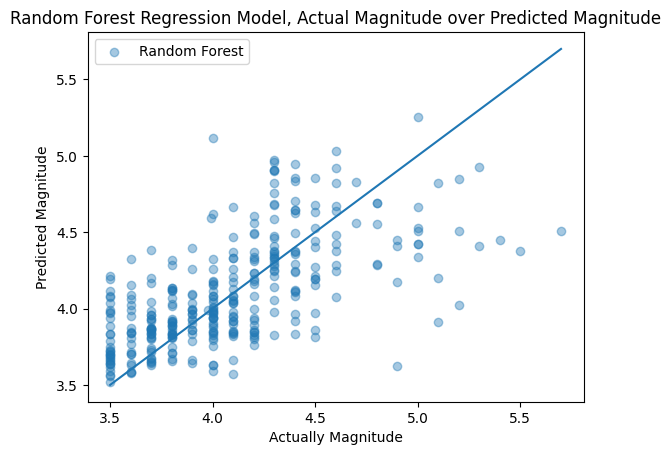

Year: 2007
MSE: 0.1410223256098423
R2 score: 0.279377717266981


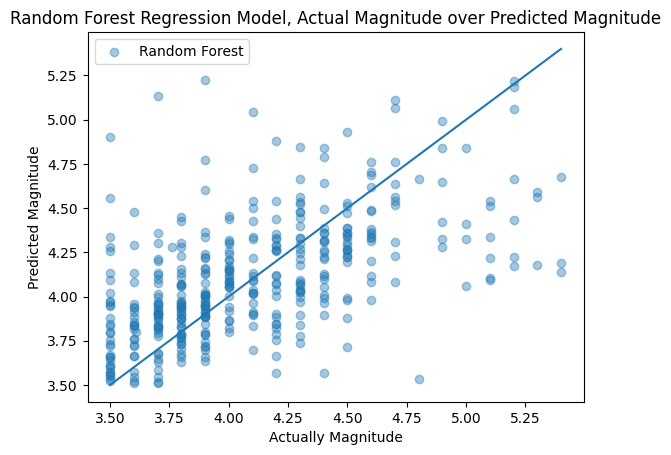

Year: 2008
MSE: 0.12606537278545993
R2 score: 0.2157784580341412


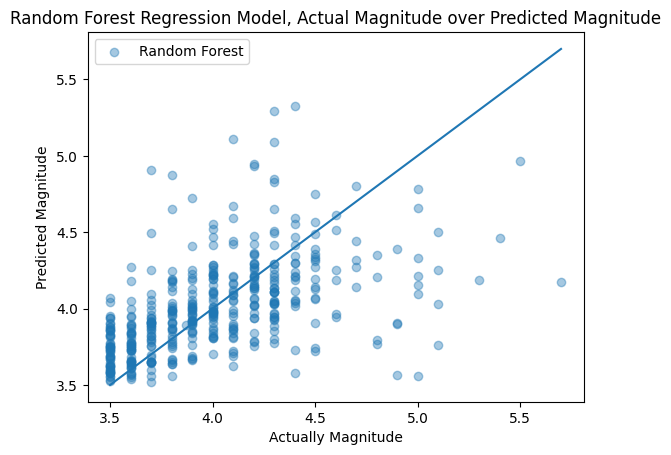

Year: 2009
MSE: 0.3084438527272734
R2 score: 0.11902546854925622


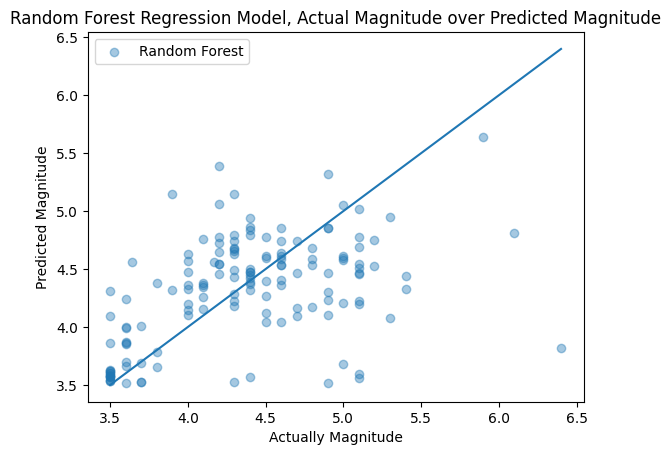

Year: 2010
MSE: 0.22757196120577236
R2 score: 0.05385374022875744


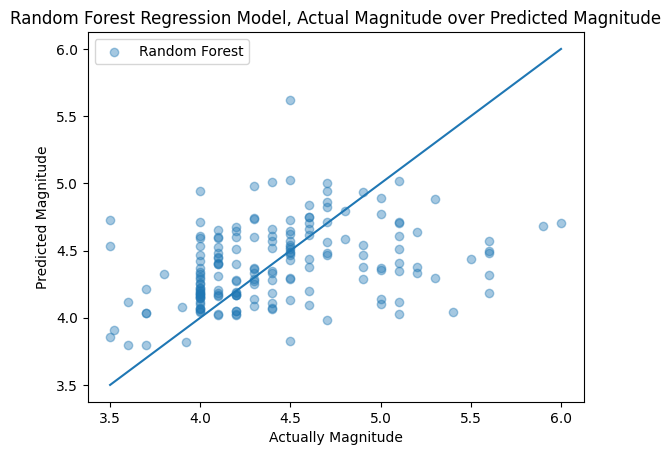

Year: 2011
MSE: 0.16072290099955588
R2 score: 0.07069248197055333


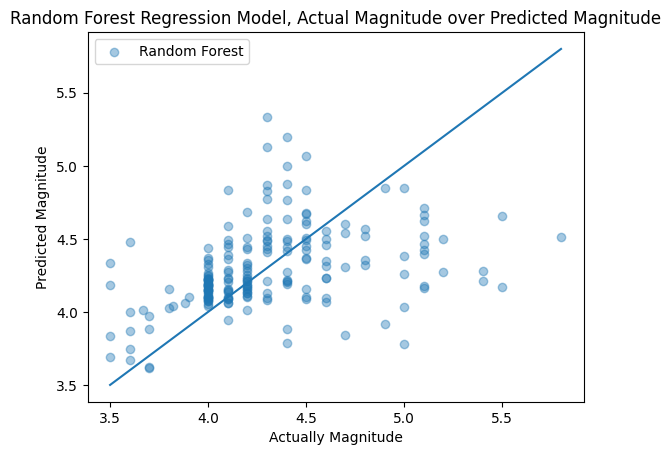

Year: 2012
MSE: 0.14130126295821446
R2 score: -0.04423142140975722


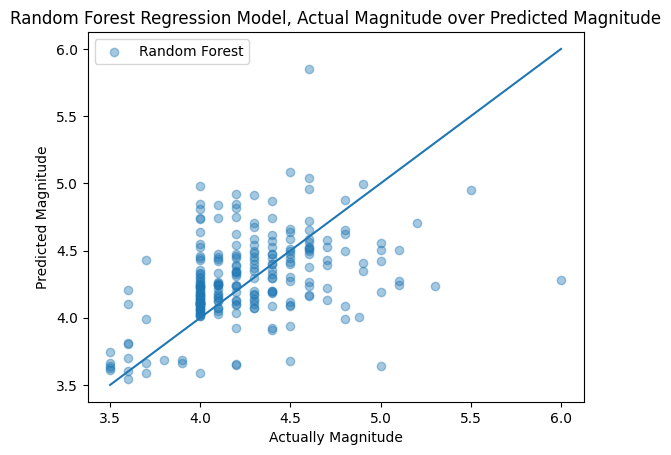

In [25]:
for year, tempGroup in south_earthquakes:
  x=tempGroup[["depth", "longitude"]]
  y=tempGroup["mag"]
  X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
  randFor_model = RandomForestRegressor(n_estimators=300, random_state=42)
  randFor_model.fit(X_train, y_train)
  randFor_predict = randFor_model.predict(X_test)

  print("Year:", year)
  mse = mean_squared_error(y_test, randFor_predict)
  r2 = r2_score(y_test, randFor_predict)
  print(f"MSE: {mse}")
  print(f"R2 score: {r2}")

  plt.scatter(y_test, randFor_predict, alpha=0.4, label="Random Forest")
  #how to plot line regression using min max of y_test
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
  plt.xlabel("Actually Magnitude")
  plt.ylabel("Predicted Magnitude")
  plt.title("Random Forest Regression Model, Actual Magnitude over Predicted Magnitude")
  plt.legend()
  plt.show()




MagType instead of by year

Mag Type: mb
MSE: 0.0844956311083571
R2 score: 0.05086156055312885


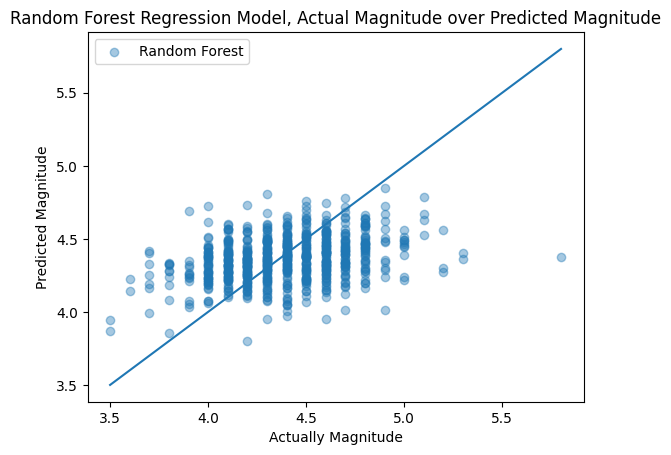

Mag Type: md
MSE: 0.03771270537751664
R2 score: 0.5068523457071534


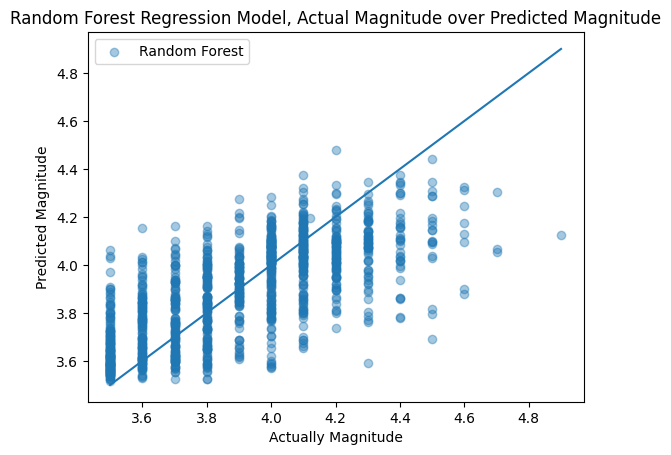

Mag Type: ml
MSE: 0.11933801778124797
R2 score: 0.09922694226285478


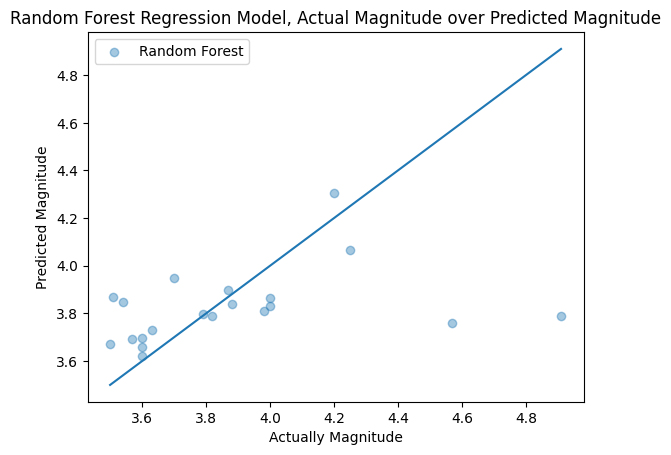

Mag Type: mw
MSE: 0.14254503273809288
R2 score: -0.01719028216017726


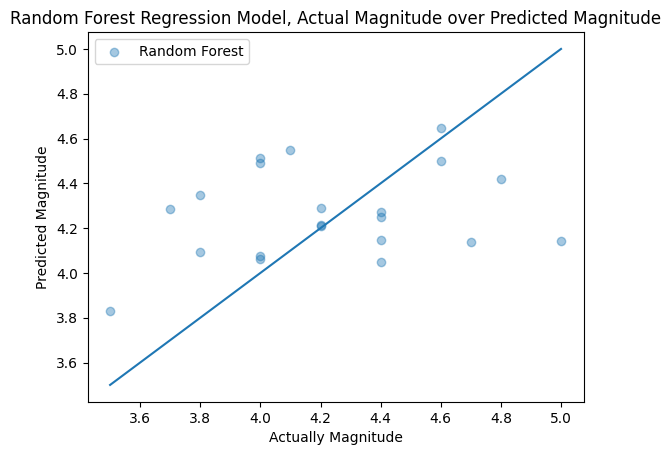

Mag Type: mwb
MSE: 0.28287258035714746
R2 score: -0.09118334481403068


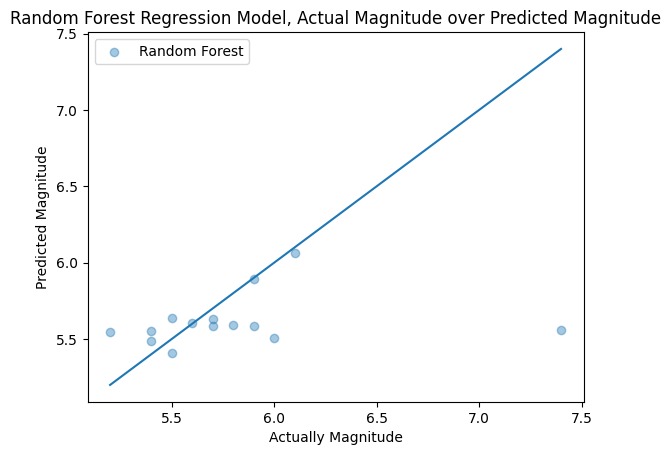

Mag Type: mwc
MSE: 0.11814640150000136
R2 score: 0.12090939577439319


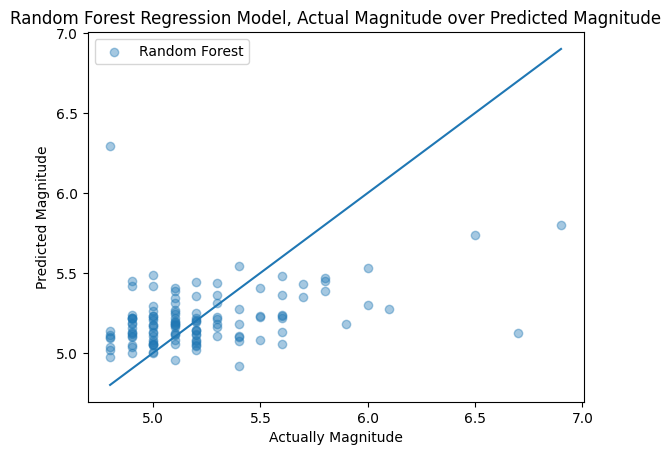

Mag Type: mwr
MSE: 0.3251882499999942
R2 score: -1.6854255483870482


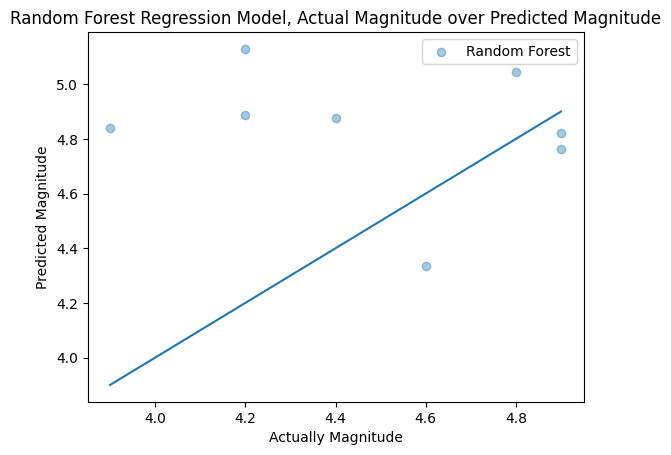

Mag Type: mww
MSE: 0.3086975937500052
R2 score: -5.9565654929578535


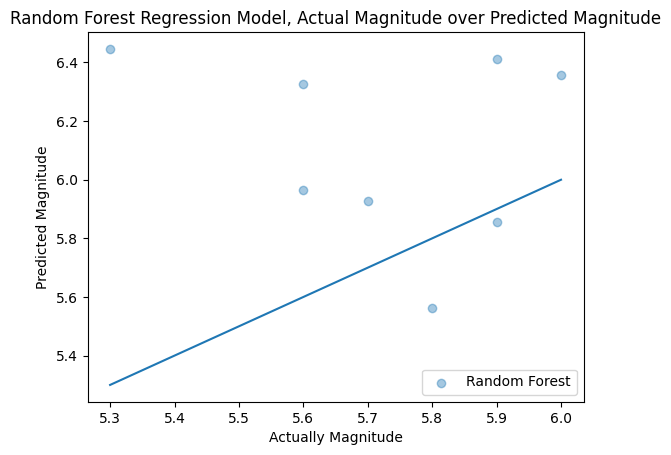

In [26]:
magType_df = region.groupby("magType")
for magType, tempGroup in magType_df:
  if len(tempGroup) < 30:
    continue
  x=tempGroup[["depth", "latitude","longitude", "year"]]
  y=tempGroup["mag"]
  X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
  randFor_model = RandomForestRegressor(n_estimators=400, random_state=42)
  randFor_model.fit(X_train, y_train)
  randFor_predict = randFor_model.predict(X_test)

  print("Mag Type:", magType)
  mse = mean_squared_error(y_test, randFor_predict)
  r2 = r2_score(y_test, randFor_predict)
  print(f"MSE: {mse}")
  print(f"R2 score: {r2}")

  plt.scatter(y_test, randFor_predict, alpha=0.4, label="Random Forest")
  #how to plot line regression using min max of y_test
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
  plt.xlabel("Actually Magnitude")
  plt.ylabel("Predicted Magnitude")
  plt.title("Random Forest Regression Model, Actual Magnitude over Predicted Magnitude")
  plt.legend()
  plt.show()

  

Lets try and predict earthquake frequency over time in the northern hemisphere. What about in a certain region? We will use Linear Regression. Because we are trying to predict time, we should not split the data randomly, we will train past years and months and we will train with future years and months.

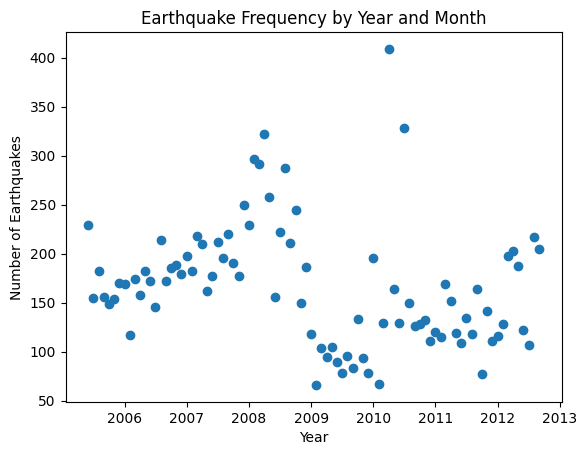

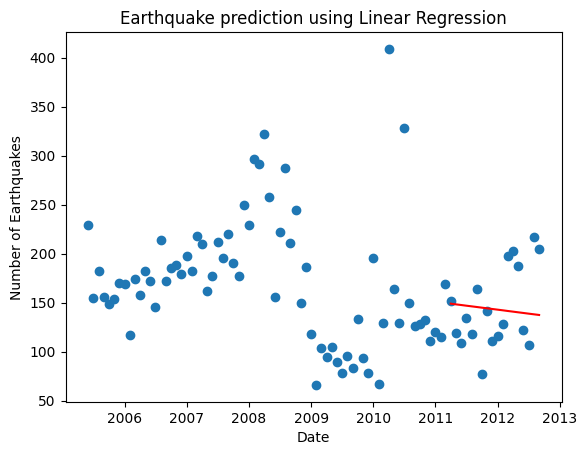

MSE: 1756.619307394474
MAE: 35.3524421893681
R2 score: -0.09591678463065922


In [29]:
earthquakes_ml_dataframe = pd.DataFrame()
earthquakes_ml_dataframe['year'] = pd.to_datetime(earthquakes_df['date']).dt.year
earthquakes_ml_dataframe['month'] = pd.to_datetime(earthquakes_df['date']).dt.month
earthquakes_ml_dataframe['place'] = earthquakes_df['place']


#count earthquakes per year per month
earthquakes_monthly = earthquakes_ml_dataframe.groupby(['year', 'month']).size().reset_index(name='Number of earthquakes')

earthquakes_monthly['date'] = pd.to_datetime(
    earthquakes_monthly[['year', 'month']].assign(day=1)
)


#i need to create a continuous time variable 
earthquakes_monthly['continuous_time'] = range(len(earthquakes_monthly))

#see the plot and see if we can see a trend over the years
plt.scatter(earthquakes_monthly['date'], earthquakes_monthly['Number of earthquakes'])
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.title('Earthquake Frequency by Year and Month')
plt.show()


#it needs to have 2 [[]] because it needs to be a 2D array for the model to work,
#if it was just one [] it would be a 1D array and the model would not work
X = earthquakes_monthly[['continuous_time']]
Y = earthquakes_monthly['Number of earthquakes']


#20% will be test, 80% will be train
where_to_split_data = int(len(X) * 0.8)
X_train = X[: where_to_split_data]
X_test = X[where_to_split_data :]

Y_train = Y[: where_to_split_data]
Y_test = Y[where_to_split_data :]




#Linear Regression
model = LinearRegression()
model.fit(X_train, Y_train)
model_pred = model.predict(X_test)


plt.scatter(earthquakes_monthly['date'], earthquakes_monthly['Number of earthquakes'],
            label='Actual earthquakes')

plt.plot(earthquakes_monthly['date'][where_to_split_data:], model_pred, color='red',
         label='Prediction Linear Regression')

plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.title('Earthquake prediction using Linear Regression')
plt.show()


model_mse = mean_squared_error(Y_test, model_pred)
model_r2 = r2_score(Y_test, model_pred)
model_mae = mean_absolute_error(Y_test, model_pred)

print(f"MSE: {model_mse}")
print(f"MAE: {model_mae}")
print(f"R2 score: {model_r2}")




The Linear Regression did not work because the earthquake frequency does not change linearily. Lets try Polynomial Regression, the graph looks like it has a curve.



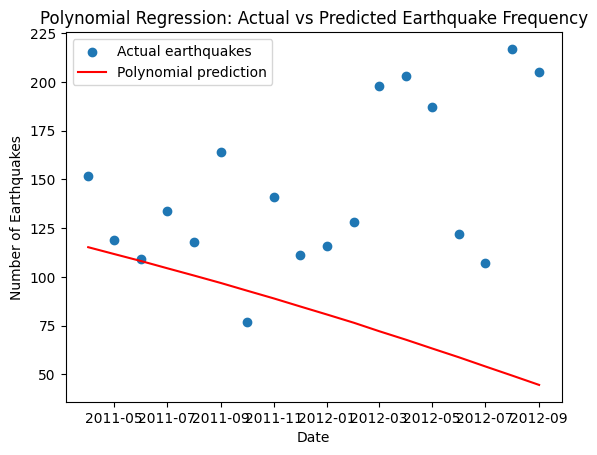

MSE: 6934.053973471881
MAE: 64.97710734426579
R2 score: -3.3260062684465614


In [30]:
poly = PolynomialFeatures(degree=2)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train, Y_train)

model_pred = model.predict(X_test)

model_mse = mean_squared_error(Y_test, model_pred)
model_r2 = r2_score(Y_test, model_pred)
model_mae = mean_absolute_error(Y_test, model_pred)

plt.scatter(
    earthquakes_monthly['date'][where_to_split_data:],
    Y_test,
    label='Actual earthquakes'
)

# Polynomial predictions
plt.plot(
    earthquakes_monthly['date'][where_to_split_data:],
    model_pred,
    color='red',
    label='Polynomial prediction'
)

plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.title('Polynomial Regression: Actual vs Predicted Earthquake Frequency')

plt.legend()
plt.show()

print(f"MSE: {model_mse}")
print(f"MAE: {model_mae}")
print(f"R2 score: {model_r2}")




The polynomial model is performing even worse than the linear model.


#**Insights & Conclusions**
